170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
Zero-Shot Accuracy (TF-IDF Simple): 15.00%


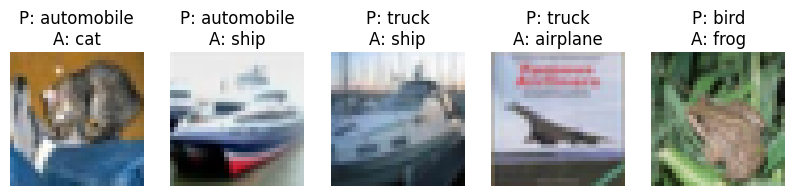

Zero-shot components saved successfully!
Please enter the path to your image: /content/images.jpg
------------------------------
Prediction: BIRD
Similarity Score: 0.5007
------------------------------


In [1]:
import pickle
import joblib
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
subset_size = 100
images, labels = x_test[:subset_size], y_test[:subset_size].flatten()
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(32, 32, 3))
processed_imgs = preprocess_input(images.astype('float32'))
image_features = base_model.predict(processed_imgs)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

descriptions = [
       """airplane aircraft jet plane fighter commercial airliner aviation flying
          sky wings propeller cockpit fuselage tail flight aviation vehicle airborne
          pilot passenger cargo military civilian transport airbus boeing metal fast""",
     """automobile car sedan vehicle road street driving motor engine wheels
          tire transport highway automotive coupe hatchback convertible SUV
          passenger commercial racing sports luxury compact family transportation metal""",
     """bird avian flying feathers wings beak animal creature wildlife sparrow
          eagle hawk pigeon dove robin cardinal finch flight sky tree perch nest
          singing chirping small colorful nature outdoor wild pet organic""",
     """cat feline kitten pet domestic animal mammal furry whiskers meow purr
          tabby persian siamese calico orange black white striped spotted ears
          tail paws claws hunter playful cute adorable companion house organic""",
     """deer animal wildlife mammal antlers forest woodland buck doe fawn
          herbivore nature wild brown tan white spots running jumping graceful
          hunting game venison elk reindeer moose caribou outdoor organic""",
     """dog canine puppy pet domestic animal mammal furry tail bark woof
          retriever terrier bulldog poodle shepherd husky companion loyal
          friendly playful hunting guard working service therapy family organic""",
     """frog amphibian animal creature green wet water pond lake swamp marsh
          jumping hopping croaking ribbit tadpole legs webbed tropical rainforest
          slimy smooth skin eyes bulging small reptile toad organic living""",
     """horse equine stallion mare pony animal mammal riding galloping trotting
          racing farm ranch stable brown black white chestnut mane tail hooves
          saddle bridle equestrian western cowboy wild mustang thoroughbred organic""",
     """ship boat vessel maritime ocean sea water sailing cruise cargo container
          freight navy military warship battleship destroyer cruiser yacht sailboat
          speedboat hull deck mast anchor port harbor dock naval marine metal""",
     """truck vehicle transportation cargo delivery pickup heavy large commercial
          freight hauling semi trailer lorry flatbed dump moving van wheels diesel
          road highway transport highway transport logistics shipping construction industrial metal"""
]

vectorizer = TfidfVectorizer()
label_embeddings_original = vectorizer.fit_transform(descriptions).toarray()

from sklearn.decomposition import PCA

# Determine a common dimensionality for PCA
# image_features has 100 samples. label_embeddings_original has 10 samples (descriptions) and 233 features.
# PCA on image_features can have max 100 components.
# PCA on label_embeddings_original can have max 10 components.
# To compare them with cosine_similarity, they must have the same number of features.
# The common bottleneck is 10 components.
n_components_common = min(image_features.shape[0], label_embeddings_original.shape[0])

# Apply PCA to image_features
pca_image = PCA(n_components=n_components_common)
image_features_reduced = pca_image.fit_transform(image_features)

# Apply PCA to label_embeddings_original
pca_label = PCA(n_components=n_components_common)
label_embeddings_reduced = pca_label.fit_transform(label_embeddings_original)

similarity_matrix = cosine_similarity(image_features_reduced, label_embeddings_reduced)
predictions = np.argmax(similarity_matrix, axis=1)
acc = accuracy_score(labels, predictions)
print(f"Zero-Shot Accuracy (TF-IDF Simple): {acc * 100:.2f}%")


plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i])
    plt.title(f"P: {class_names[predictions[i]]}\nA: {class_names[labels[i]]}")
    plt.axis('off')
plt.show()

# Save both PCA models and the reduced label embeddings
joblib.dump(pca_image, 'zsl_pca_image.joblib')
joblib.dump(pca_label, 'zsl_pca_label.joblib')
joblib.dump(vectorizer, 'zsl_tfidf.joblib')
np.save('label_embeddings_reduced.npy', label_embeddings_reduced)
with open('class_names.pkl', 'wb') as f:
    pickle.dump(class_names, f)

print("Zero-shot components saved successfully!")

import numpy as np
import tensorflow as tf
import joblib
import pickle
import os
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from sklearn.metrics.pairwise import cosine_similarity

def run_prediction():
    try:
        # Load both PCA models
        pca_image = joblib.load('zsl_pca_image.joblib')
        pca_label = joblib.load('zsl_pca_label.joblib') # Loaded but not used if new descriptions aren't processed
        vectorizer = joblib.load('zsl_tfidf.joblib') # Only needed if new descriptions are given
        label_embeddings_reduced = np.load('label_embeddings_reduced.npy')
        with open('class_names.pkl', 'rb') as f:
            class_names = pickle.load(f)
    except FileNotFoundError:
        print("Error: Model components not found. Please run the training script first.")
        return

    base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg', input_shape=(32, 32, 3))

    image_path = input("Please enter the path to your image: ").strip()

    if not os.path.exists(image_path):
        print(f"Error: File '{image_path}' not found.")
        return

    img = tf.keras.utils.load_img(image_path, target_size=(32, 32))
    img_array = tf.keras.utils.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    processed_img = preprocess_input(img_batch.astype('float32'))

    raw_features = base_model.predict(processed_img, verbose=0)
    # Apply the image PCA to the new image features
    reduced_features = pca_image.transform(raw_features)

    # Use the pre-reduced label_embeddings for similarity calculation
    similarities = cosine_similarity(reduced_features, label_embeddings_reduced)

    best_idx = np.argmax(similarities)
    confidence = similarities[0][best_idx]

    print("-" * 30)
    print(f"Prediction: {class_names[best_idx].upper()}")
    print(f"Similarity Score: {confidence:.4f}")
    print("-" * 30)

if __name__ == "__main__":
    run_prediction()
